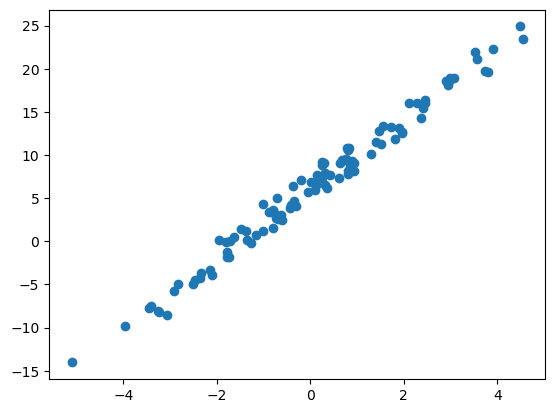

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)

# y = 4X + 6 을 근사 (w1 = 4, w0 = 6), 임의의 값은 노이즈를 위해 만듦
X = 2 * np.random.randn(100, 1)

y = 6 + 4 * X + np.random.randn(100, 1)

# X, y 데이터 세트 산점도로 시각화 
plt.scatter(X, y)
plt.show()

In [2]:
def get_cost(y, y_pred):
    N= len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost

In [3]:
# w1 과 w0 을 업데이트할 w1_update, w0_update를 반환 

def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화 
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    #예측 배열 계산하고 예측과 실제 값의 차이 계산 
    y_pred = np.dot(X, w1.T) + w0
    diff = y-y_pred
    #w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진행렬 생성 
    w0_factors = np.ones((N, 1))
    #w1 과 W0을 업데이트할 w1_update와 w0 update 계산
    w1_update = -(2/N)*learning_rate*(np.dot(X.T,diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))
    return w1_update, w0_update
    

In [4]:
#입력 인자 iters 로 주어진 횟수 만큼 반복적으로 w1 과 w0를 업데이트 적용함
def gradient_descent_steps(X,y, iters = 10000):
    #w0 와 w1을 모두 0으로 초기화 
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    #인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행 
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    return w1, w0

In [5]:
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y-y_pred))/N
    return cost
w1, w0 = gradient_descent_steps(X, y, iters= 1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0, 0], w0[0, 0]))
y_pred = w1[0, 0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))


w1:4.057 w0:6.075
Gradient Descent Total Cost:1.0572


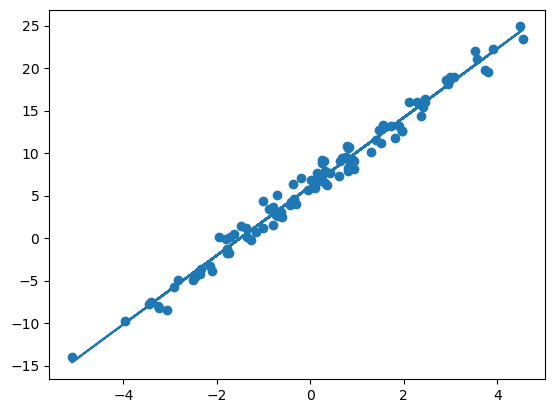

In [6]:
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.show()

In [7]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters = 1000):
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))
    for ind in range (iters):
        np.random.seed(ind)
        #전체 X, y 데이터 에서 랜덤하게 batch_size 만큽 데이터를 추출해 sample_X, sample_Y로 저장 
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        #랜덤하게 batch_size 만큼 추출된 데이터를 기반으로 w1_update, w0 update를 계산 후 업데이트 
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate = 0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    return w1, w0

w1, w0 = stochastic_gradient_descent_steps(X, y, iters = 1000)
print("w1:", round(w1[0, 0], 3), "w0:", round(w0[0, 0], 3))
y_pred = w1[0, 0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.072 w0: 6.064
Stochastic Gradient Descent Total Cost:1.0582


In [8]:
#class sklearn.linear_model.LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs = 1)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston 
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')

%matplotlib inline

#boston 데이터 세트 로드 
boston = load_boston()

#보스턴 데이터 세트 데이터 프레임 변환 
bostonDF = pd.DataFrame(boston.data, columns = boston.feature_names)

#보스턴 데이터 세트의 target 배열은 주택 가격임 이를 칼럼으로 DataFrame 에 추가 

boston['Price'] = boston.target
print('Boston 데이터 세트 크기: ', bostonDF.shape)
bostonDF.head

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

In [10]:
#2개의 행과 4개의 열을 가진 subplot를 이용 , axs는 4 x 2 개의 ax를 가짐
fig, axs = plt.subplots(figsize=(16, 8), ncols = 4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']
for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    #시본의 regplot을 이용해 산점도와 선형회귀 직선을 함께 표현
    sns.regplot(x=feature, y='Price',data=bostonDF, ax = axs[row][col])
    

NameError: name 'bostonDF' is not defined

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score

y_target=bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis = 1, inplace = False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size = 0.3, random_state =156)

#선형 회귀 OLS 로 학습/예측/평가 수행 
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3F}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

NameError: name 'bostonDF' is not defined

In [13]:
print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr_coef_, 1))

NameError: name 'lr' is not defined

In [14]:
#회귀 계수를 큰값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의 

coeff = pd.Series(data = np.round(lr.coef_, 1), index = X_data.columns)
coeff.sort_values(ascending = False)

NameError: name 'lr' is not defined

In [15]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['Price']
X_data = bostonDF.drop(['Price'], axis = 1, inplace = False)
lr = LinearRegression()

#cross val score 로 폴드 세트로 MSE를 구한 뒤 이를 기반으로 RMSE를 구함
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring = 'neg_mean_squared_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

#cross_val_score(scoring = 'neg_mean_squared_error" 로 반환 된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores:', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores :', np.round(rmse_scores,2))
print(' 5 folds 의 평균 RMSE :{0 :3f}'.format(avg_rmse))

NameError: name 'bostonDF' is not defined

In [16]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

#다항식으로 변환한 단항식 생성, [[0 1], [2, 3]]의 2 X 2 행렬 생성
X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 피처 :\n', X)

#degree  = 2인 2차 다항식으로 변환 하기 위해 PolynomialFeatures를 이용해 변환 
poly = PolynomialFeatures(degree = 2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 피터:\n', poly_ftr)

일차 단항식 계수 피처 :
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피터:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline 

#임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환 

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0 부터 1까지 30개의 임의 값을 순서대로 샘플링 한 값
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

#y 값은 코사인 기반의 true_fun 에서 약간의 노이즈 변동값을 더한 값이다 

y = true_fun(X) + np.random.randn(n_samples) * 0.1




Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986834 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987231747 입니다.

Degree 15 회귀 계수는 [-2.98295000e+03  1.03899930e+05 -1.87417069e+06  2.03717225e+07
 -1.44873988e+08  7.09318780e+08 -2.47066977e+09  6.24564048e+09
 -1.15677067e+10  1.56895696e+10 -1.54006776e+10  1.06457788e+10
 -4.91379977e+09  1.35920330e+09 -1.70381654e+08] 입니다.
Degree 15 MSE 는 182815433.47648773 입니다.


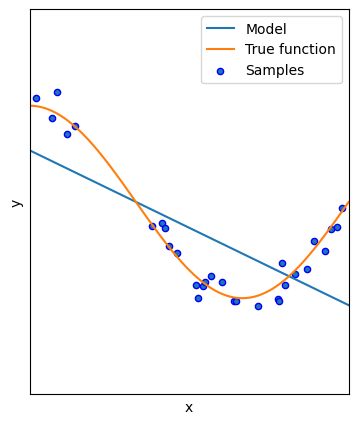

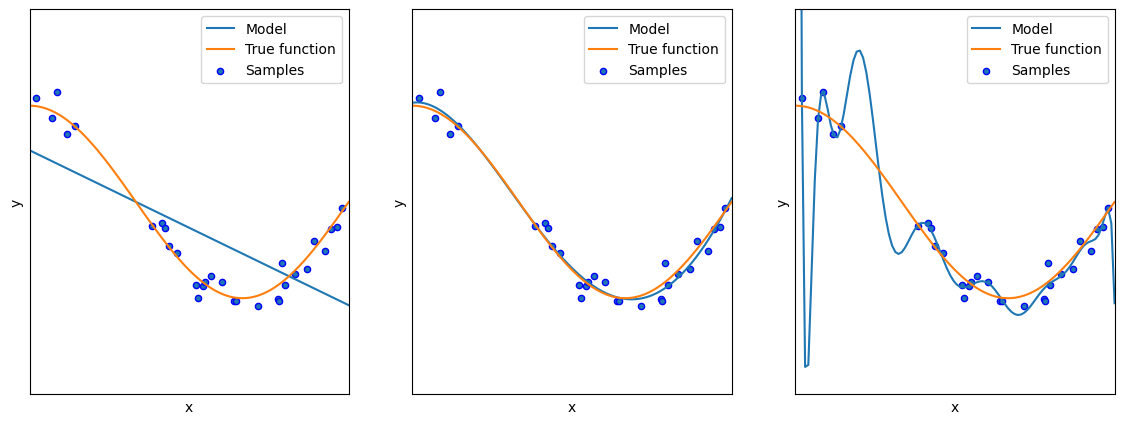

In [29]:
plt.figure(figsize = (14, 5))
degrees = [1, 4, 15]

# 다항 회귀 차수 degree를 1, 4, 15 로 각각 변환 시키면서 비교합니다. 
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks = ())
    #개별 degree 별로 Polynomial을 반환 합니다.
    polynomial_features = PolynomialFeatures(degree = degrees[i], include_bias = False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1,1), y)
    # 교차 검증으로 다항 회귀를 평가합니다. 
    scores = cross_val_score(pipeline, X.reshape(-1,1), y, scoring="neg_mean_squared_error", cv = 10)
    #Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1 * np.mean(scores)))
    
    #0 부터 1 까지 테스트 데이터 세트를 100개 나눠 예측을 수행합니다.
    #테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을  그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    #예측값 곡선 
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label = "Model")
    #실제 값 곡선 
    plt.plot(X_test, true_fun(X_test), '-', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label = "Samples")
    plt.xlabel("x");plt.ylabel("y");plt.xlim((0, 1));plt.ylim((-2, 2)); plt.legend(loc="best")
    
plt.show()

In [30]:
plt.title("Degree {}\nMSE = {:.2e}(+/-{:.2e})".format(degrees[i] -scores.mean(), scores.std()))

IndexError: Replacement index 2 out of range for positional args tuple